# Notebook 1 — Representación de señales y transformada de Fourier

## Objetivo

En este notebook se estudia de manera experimental la representación de señales en el dominio temporal y en el dominio frecuencial. El objetivo es ilustrar tres ideas fundamentales para el desarrollo posterior del TFG:

1. una señal puede modelarse como combinación de componentes sinusoidales simples;
2. la transformada discreta de Fourier permite identificar las frecuencias presentes en la señal;
3. muchas señales presentan una representación más compacta en el dominio frecuencial que en el dominio temporal.

Este análisis constituye la base conceptual para introducir posteriormente el teorema de Shannon--Nyquist, la noción de sparsidad y el marco de *Compressed Sensing*.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Configuración gráfica
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

## 1. Definición de parámetros de muestreo

Se fija una frecuencia de muestreo y una duración total de observación. A partir de estos parámetros se construye el eje temporal discreto sobre el que se evaluarán las señales.

In [2]:
# Parámetros globales
fs = 500              # frecuencia de muestreo en Hz
T = 1.0               # duración total en segundos
N = int(fs * T)       # número total de muestras

t = np.linspace(0, T, N, endpoint=False)

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Duración total: {T} s")
print(f"Número de muestras: {N}")

Frecuencia de muestreo: 500 Hz
Duración total: 1.0 s
Número de muestras: 500


## 2. Funciones auxiliares

Se definen varias funciones para:

- calcular la transformada discreta de Fourier,
- reconstruir señales,
- conservar únicamente los coeficientes más significativos,
- y medir el error de reconstrucción.

In [4]:
def compute_fft(signal, fs):
    """
    Calcula la FFT de una señal y devuelve frecuencias positivas y magnitudes.
    """
    N = len(signal)
    fft_coeffs = np.fft.fft(signal)
    freqs = np.fft.fftfreq(N, d=1/fs)

    mask = freqs >= 0
    return freqs[mask], fft_coeffs[mask], fft_coeffs


def reconstruct_from_fft(full_fft):
    """
    Reconstruye la señal usando la transformada inversa de Fourier.
    """
    return np.fft.ifft(full_fft).real


def keep_top_k_coeffs(full_fft, k):
    """
    Conserva los k coeficientes de mayor magnitud y anula el resto.
    """
    fft_copy = np.copy(full_fft)
    magnitudes = np.abs(fft_copy)

    # Índices de los k coeficientes de mayor magnitud
    top_k_idx = np.argsort(magnitudes)[-k:]

    filtered_fft = np.zeros_like(fft_copy, dtype=complex)
    filtered_fft[top_k_idx] = fft_copy[top_k_idx]
    return filtered_fft


def mse(x, x_hat):
    return np.mean((x - x_hat) ** 2)


def relative_error(x, x_hat):
    return np.linalg.norm(x - x_hat) / np.linalg.norm(x)

## 3. Experimento 1: señal sinusoidal simple

Se comienza con una señal elemental compuesta por una única senoide. Este experimento permite comprobar que una señal simple en el dominio temporal genera un espectro con una frecuencia dominante claramente identificable.

In [6]:
# Señal 1: senoide simple
f1 = 5  # Hz
signal_1 = np.sin(2 * np.pi * f1 * t)

freqs_1, fft_pos_1, fft_full_1 = compute_fft(signal_1, fs)
magnitude_1 = np.abs(fft_pos_1) / N

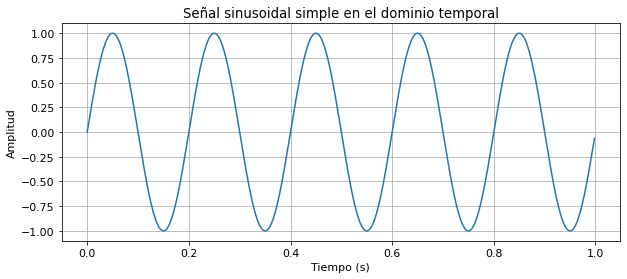

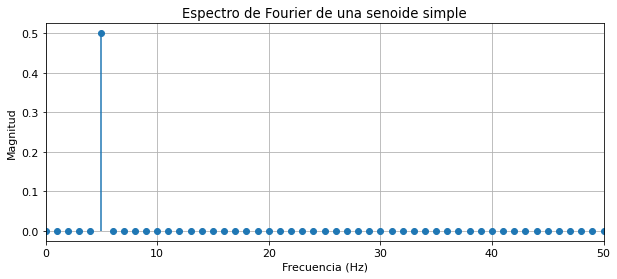

In [7]:
# Señal en el dominio temporal
plt.figure()
plt.plot(t, signal_1)
plt.title("Señal sinusoidal simple en el dominio temporal")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.show()

# Espectro de Fourier
plt.figure()
plt.stem(freqs_1, magnitude_1, basefmt=" ")
plt.xlim(0, 50)
plt.title("Espectro de Fourier de una senoide simple")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.show()

### Comentario

Tal como cabía esperar, el espectro presenta un pico dominante en la frecuencia correspondiente a la senoide generada. Esto confirma que la transformada de Fourier identifica correctamente la estructura oscilatoria básica de la señal.